# Introduction to Unsupervised Learning
### Hands-on Notebook

**Learning Objectives**
1. Define the **scope of Unsupervised Learning**
2. Understand **patterns in unlabeled data**

---
A music streaming service has listener behavior data with no genre labels. We'll show that structure can still be found — using nothing but distance between data points.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

np.random.seed(21)


## 1. The listener dataset — no labels anywhere

Two features per listener: average song length before a skip, and skip rate. No genre, no group, no target column at all.


In [2]:
group_a = np.random.normal([3.0, 0.15], [0.3, 0.05], size=(4, 2))
group_b = np.random.normal([7.5, 0.55], [0.4, 0.06], size=(4, 2))
listeners = np.round(np.vstack([group_a, group_b]), 2)

df = pd.DataFrame(listeners, columns=["avg_song_length_min", "skip_rate"])
df.index = [chr(65 + i) for i in range(len(df))]
df


,avg_song_length_min,skip_rate
A,2.98,0.14
B,3.31,0.09
C,3.22,0.06
D,2.94,0.14
E,7.95,0.55
F,7.25,0.63
G,8.14,0.51
H,7.78,0.52


Notice: there is no column here that says which group a listener belongs to. As far as the dataset is concerned, these are just 8 rows of numbers.


## 2. Visualizing the data — before looking for structure

Plot the listeners with a single, uniform color. This is genuinely all the information a fully unlabeled dataset gives you.


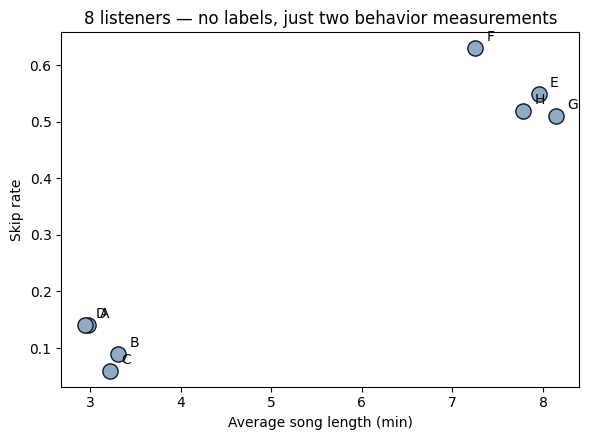

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(df["avg_song_length_min"], df["skip_rate"], s=120, color="#93AAC4", edgecolor="#0D1A2B")
for name, row in df.iterrows():
    ax.annotate(name, (row["avg_song_length_min"], row["skip_rate"]), textcoords="offset points", xytext=(8, 5))
ax.set_xlabel("Average song length (min)")
ax.set_ylabel("Skip rate")
ax.set_title("8 listeners — no labels, just two behavior measurements")
plt.tight_layout(); plt.show()


## 3. Distance is the only signal we have

Without labels, we fall back on a very simple idea: points that are numerically close together probably share behavior. Let's compute every pairwise distance.


In [4]:
dist_matrix = squareform(pdist(listeners))
dist_df = pd.DataFrame(dist_matrix, index=df.index, columns=df.index).round(2)
dist_df


,A,B,C,D,E,F,G,H
A,0.00,0.33,0.25,0.04,4.99,4.30,5.17,4.82
B,0.33,0.00,0.09,0.37,4.66,3.98,4.85,4.49
C,0.25,0.09,0.00,0.29,4.76,4.07,4.94,4.58
D,0.04,0.37,0.29,0.00,5.03,4.34,5.21,4.85
E,4.99,4.66,4.76,5.03,0.00,0.70,0.19,0.17
F,4.30,3.98,4.07,4.34,0.70,0.00,0.90,0.54
G,5.17,4.85,4.94,5.21,0.19,0.90,0.00,0.36
H,4.82,4.49,4.58,4.85,0.17,0.54,0.36,0.00


**Checkpoint:** look at the block structure — distances among {A, B, C, D} and among {E, F, G, H} should be small, while every distance *between* those two sets should be much larger. That block pattern is the "no labels" version of a cluster.


In [5]:
within_ab = dist_matrix[:4, :4][np.triu_indices(4, k=1)]
within_ef = dist_matrix[4:, 4:][np.triu_indices(4, k=1)]
across = dist_matrix[:4, 4:].flatten()

avg_within = np.concatenate([within_ab, within_ef]).mean()
avg_across = across.mean()

print(f"Average within-group distance: {avg_within:.3f}")
print(f"Average across-group distance: {avg_across:.3f}")
print(f"Ratio (across / within): {avg_across / avg_within:.1f}x")


Average within-group distance: 0.355
Average across-group distance: 4.690
Ratio (across / within): 13.2x


**Checkpoint:** this should match the slide — within-group ≈ 0.355, across-group ≈ 4.69, a ratio of roughly 13×.


## 4. The same idea on a larger, real dataset

Scikit-learn's `load_iris` is a genuine, well-known dataset with 150 flowers described by 4 measurements — and, like our listener data, we'll deliberately ignore its label column to see whether distance alone reveals structure.


In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data          # the 4 measurements — this is all we'll use
y_iris = iris.target        # the real species label — set aside, not used for finding structure

print(f"{X_iris.shape[0]} flowers, {X_iris.shape[1]} measurements each, 0 labels used so far")


150 flowers, 4 measurements each, 0 labels used so far


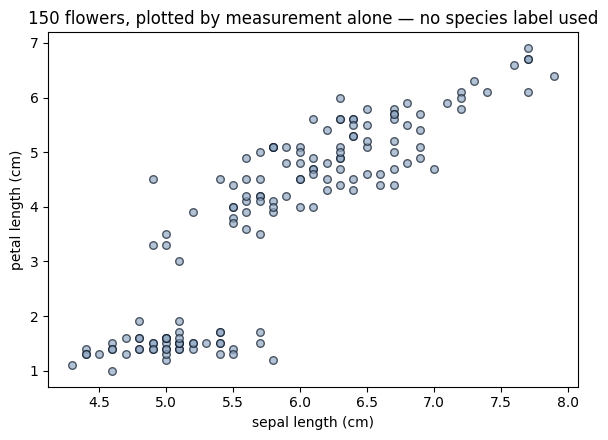

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_iris[:, 0], X_iris[:, 2], s=30, color="#93AAC4", alpha=0.7, edgecolor="#0D1A2B")
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[2])
ax.set_title("150 flowers, plotted by measurement alone — no species label used")
plt.tight_layout(); plt.show()


Even with the label completely set aside, distinguishable groupings are visible by eye in just two of the four measurements — the same phenomenon as the listener example, at a larger scale.


## 5. Exercises


**Exercise 1.** Add a 9th listener with `avg_song_length_min=5.2, skip_rate=0.35` (roughly halfway between the two groups) to `listeners`, recompute the distance matrix, and check which existing listener it's closest to.


In [8]:
# TODO



<details><summary>Solution</summary>

```python
listeners_v2 = np.vstack([listeners, [5.2, 0.35]])
dist_v2 = squareform(pdist(listeners_v2))
new_row = dist_v2[-1, :-1]
closest = df.index[np.argmin(new_row)]
print(closest, new_row.min())
```
A listener genuinely in between two clusters won't have an obviously "correct" group — its nearest neighbor might be a boundary member of either cluster, which is a realistic preview of why cluster *assignment* (covered in the next session) needs more than just "find the nearest point."
</details>


**Exercise 2.** Using `iris.feature_names`, print which two features were plotted in Section 4 (index 0 and index 2), and compute the correlation between them using `np.corrcoef`.


In [9]:
# TODO



<details><summary>Solution</summary>

```python
print(iris.feature_names[0], iris.feature_names[2])
print(np.corrcoef(X_iris[:, 0], X_iris[:, 2])[0, 1])
```
</details>


**Exercise 3.** Compute the average pairwise distance among *all 150* iris flowers (ignoring species), and compare it to the average pairwise distance among just the first 50 rows (which happen to all be one species, `setosa`). What does the difference suggest?


In [10]:
# TODO



<details><summary>Solution</summary>

```python
all_avg = pdist(X_iris).mean()
setosa_avg = pdist(X_iris[:50]).mean()
print(all_avg, setosa_avg)
```
The within-species average is meaningfully smaller than the all-flowers average — exactly the same "tighter within a group" signal from the listener example, now confirmed on a dataset whose true grouping (species) we happen to know but never used to compute it.
</details>


## 6. Recap

- **Unsupervised learning** works with data that has no target label — only its own features.
- Its scope covers at least three kinds of questions: **clustering** (which rows are alike), **dimensionality reduction** (what's the essential shape), and **anomaly detection** (what doesn't fit).
- **Distance** is the basic signal nearly every method builds on: points close together in feature space tend to share behavior, and that alone was enough to reveal real structure in both a tiny hand-built dataset and a genuine 150-row dataset.
